In [58]:
import sys
from likelihood import subtract_signal
from pycbc.conversions import mchirp_from_mass1_mass2, mass1_from_mchirp_q, mass2_from_mchirp_q
from plot_results import convert_signal, comparison_signals, comparison_freq, qtrans_plot, gwpy_to_pycbc, pycbc_to_gwpy
sys.path.append('/home/victor-glorieux/Internship_Victor_CBC_ET')
from fonctions import instruments_PSD, antenna_factors
from generation_signal import generation_signal_GW
from generate_data import generate_frequency_domain_signal

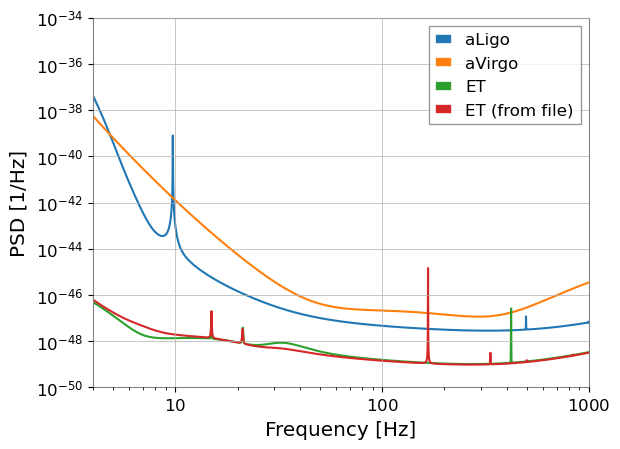

In [3]:
dict = {'aLigo' : 'aLIGOAPlusDesignSensitivityT1800042',
        'aVirgo' : 'AdvVirgo',
        'ET' : 'EinsteinTelescopeP1600143'}

instruments_PSD(dict,ET_MDC = True)

In [ ]:
cbc_params = {
              'mass1': 38.6,
              'mass2': 29.3,
              'spin1x': 0., 'spin2x': 0.,  'spin1y': 0., 'spin2y': 0.,  'spin1z': 0, 'spin2z': 0, 
              'eccentricity': 0,
              'ra': 1.37, 'dec': -1.26, 'distance': 10000, 
              'polarization': 2.76, 'inclination': 0,
              'tc': 3.1 , 'coa_phase': 0.3,
              'approximant': 'IMRPhenomXPHM',
              'f_lower': 5
                }

sample_rate = 2048
fmin = 4
model, log_noise_likelihood_from_SNR, signal = generation_signal_GW(cbc_params,sample_rate,fmin,noise = True)

AttributeError: 'FrequencySeries' object has no attribute 'get_sample'

Waveform approximate duration: 31.9s
Segment duration: 64.0s
{'E1': <pycbc.types.frequencyseries.FrequencySeries object at 0x7f0d5fe97df0>, 'E2': <pycbc.types.frequencyseries.FrequencySeries object at 0x7f0d5fe97130>, 'E3': <pycbc.types.frequencyseries.FrequencySeries object at 0x7f0d5fe97400>}
{'E1': <pycbc.types.frequencyseries.FrequencySeries object at 0x7f0d5437efa0>, 'E2': <pycbc.types.frequencyseries.FrequencySeries object at 0x7f0d3ed337f0>, 'E3': <pycbc.types.frequencyseries.FrequencySeries object at 0x7f0d54431cd0>}
Waveform approximate duration: 31.0s
Segment duration: 64.0s


/home/victor-glorieux/.conda/envs/cop_adrian/lib/python3.9/site-packages/gwpy/types/series.py:131: UserWarning: xindex was given to TimeSeries(), x0 will be ignored
  warn("xindex was given to %s(), x0 will be ignored"


Waveform approximate duration: 39.3s
Segment duration: 64.0s
Waveform approximate duration: 55.4s
Segment duration: 64.0s


(2.7, 3.18)

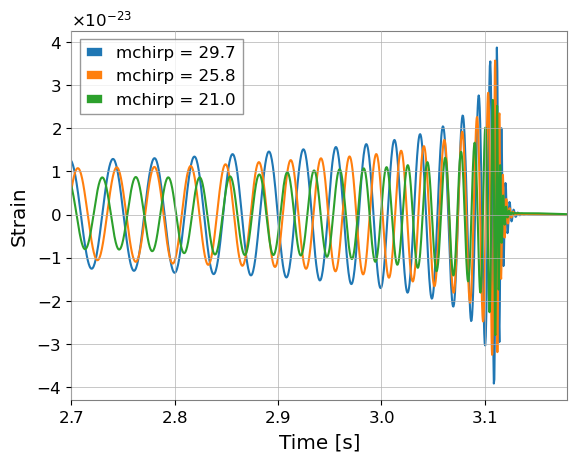

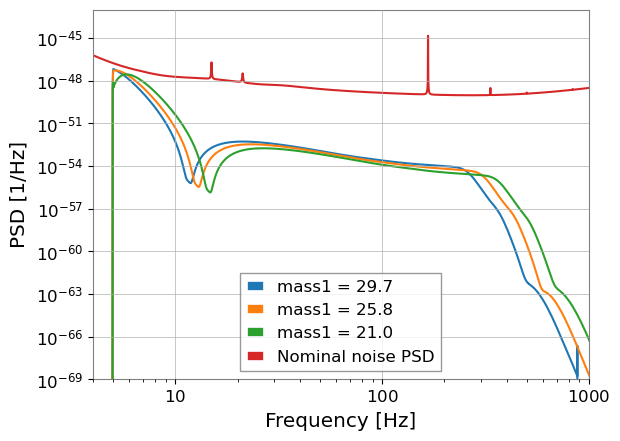

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from pycbc.types import FrequencySeries
from likelihood import MDCGaussianNoise

cbc_params = {
              'mass1': 38.6,
              'mass2': 29.3,
              'spin1x': 0., 'spin2x': 0.,  'spin1y': 0., 'spin2y': 0.,  'spin1z': 0, 'spin2z': 0, 
              'eccentricity': 0,
              'ra': 1.37, 'dec': -1.26, 'distance': 10000, 
              'polarization': 2.76, 'inclination': 0,
              'tc': 3.1 , 'coa_phase': 0.3,
              'approximant': 'IMRPhenomXPHM',
              'f_lower': 5
                }

ifos=['E1', 'E2', 'E3']
signal = generate_frequency_domain_signal(cbc_params, ifos=ifos)
print(signal)
ts_signal = {}
psds = {}
psd_file = '../input/ET10km_columns.txt'
psd = np.loadtxt(psd_file, usecols=(0,3))
psd_of_f = interp1d(psd[:,0], psd[:,1], bounds_error=False, fill_value=(psd[0,1], psd[-1,1]))

for ifo in ifos :
    ts_signal[ifo] = signal[ifo].to_timeseries()

    freq_array = signal[ifo].get_sample_frequencies()
    delta_f = signal[ifo].get_delta_f()
    psd_pycbc = psd_of_f(freq_array)
    psd_pycbc = FrequencySeries(psd_pycbc, delta_f=delta_f)
    psds[ifo] = psd_pycbc

print(psds)


model = MDCGaussianNoise(signal, psds)

mass2 = cbc_params['mass2']
masses = {'A' : 40, 'B' : 30, 'C' : 20}
mchirp = {'A' : round(mchirp_from_mass1_mass2(masses['A'],mass2),1),'B' : round(mchirp_from_mass1_mass2(masses['B'],mass2),1),
          'C' : round(mchirp_from_mass1_mass2(masses['C'],mass2),2)}

fig_ts = plt.figure()
ax_ts = fig_ts.gca()
fig_fs = plt.figure()
ax_fs = fig_fs.gca()
# for key, val in masses.items():
#     cbc_params['mass1'] = val
#     model.maximized_params = cbc_params
#     reconstructed_signal_fdomain, reconstructed_signal_tdomain = model.reconstruct_signal()
#     ax_ts.plot(reconstructed_signal_tdomain['E1'].get_sample_times(),reconstructed_signal_tdomain['E1'],label = r'mchirp = {}'.format(mchirp[key]))
#     tsgwpy = pycbc_to_gwpy(reconstructed_signal_tdomain)
#     psd_opti = tsgwpy['E1'].psd()
#     ax_fs.loglog(psd_opti.frequencies,psd_opti,label = r'mass1 = {}'.format(mchirp[key]))

for key, val in masses.items():
    cbc_params['mass1'] = val
    model.maximized_params = cbc_params
    reconstructed_signal_fdomain, reconstructed_signal_tdomain = model.reconstruct_signal()
    ax_ts.plot(reconstructed_signal_tdomain['E1'].get_sample_times(),reconstructed_signal_tdomain['E1'],label = r'mchirp = {}'.format(mchirp[key]))
    tsgwpy = pycbc_to_gwpy(reconstructed_signal_tdomain)
    psd_opti = tsgwpy['E1'].psd()
    freq_array = psd_opti.frequencies
    psd_ET = FrequencySeries(psd_of_f(freq_array), delta_f=psd_pycbc.delta_f)
    val = psd_opti.value + psd_ET
    ax_fs.loglog(freq_array,psd_opti,label = r'mass1 = {}'.format(mchirp[key]))


ET10km = pd.read_csv('../input/ET10km_columns.txt',sep = ' ',names=["frequencies", "A", "B", "C"])
ax_fs.loglog(ET10km['frequencies'],ET10km['C'],label = 'Nominal noise PSD')
ax_ts.legend()
ax_fs.legend()
ax_ts.set_xlabel('Time [s]')
ax_fs.set_xlabel('Frequency [Hz]')
ax_ts.set_ylabel('Strain')
ax_fs.set_ylabel('PSD [1/Hz]')
plt.tight_layout

ax_fs.set_xlim(4,1000)
ax_fs.set_ylim(10e-70,10e-44)

ax_ts.set_xlim(2.7,3.18)
